In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

Matplotlib is building the font cache; this may take a moment.


In [2]:
import sys
from packaging import version
import sklearn

assert sys.version_info >= (3, 7) #This line checks that the version of Python being used is 3.7 or higher
assert version.parse(sklearn.__version__) >= version.parse("1.0.1") #This line checks that the version of Scikit-learn being used is 1.0.1 or higher.
     

In [4]:
from pathlib import Path  # Importing the Path class from the pathlib module to handle file system paths
import pandas as pd  # Importing pandas as pd for data manipulation and analysis
import tarfile  # Importing the tarfile module to work with tar archive files
import urllib.request  # Importing urllib.request to handle URL operations

def load_housing_data():
    # Define the path to the tarball file
    tarball_path = Path("datasets/housing.tgz")

    # Check if the tarball file already exists
    if not tarball_path.is_file():
        # Create the datasets directory if it does not exist
        Path("datasets").mkdir(parents=True, exist_ok=True)

        # URL where the dataset is located
        url = "https://github.com/ageron/data/raw/main/housing.tgz"

        # Download the tarball file from the URL to the specified path
        urllib.request.urlretrieve(url, tarball_path)

        # Open the tarball file
        with tarfile.open(tarball_path) as housing_tarball:
            # Extract all files from the tarball to the datasets directory
            housing_tarball.extractall(path="datasets")


    ##### Here is our main activity ######
    # Load the housing.csv file into a pandas DataFrame and return it
    return pd.read_csv(Path("datasets/housing/housing.csv"))

# Call the function to load the housing data into a DataFrame
housing = load_housing_data()

In [5]:
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [6]:
housing.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [7]:
housing["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [8]:
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


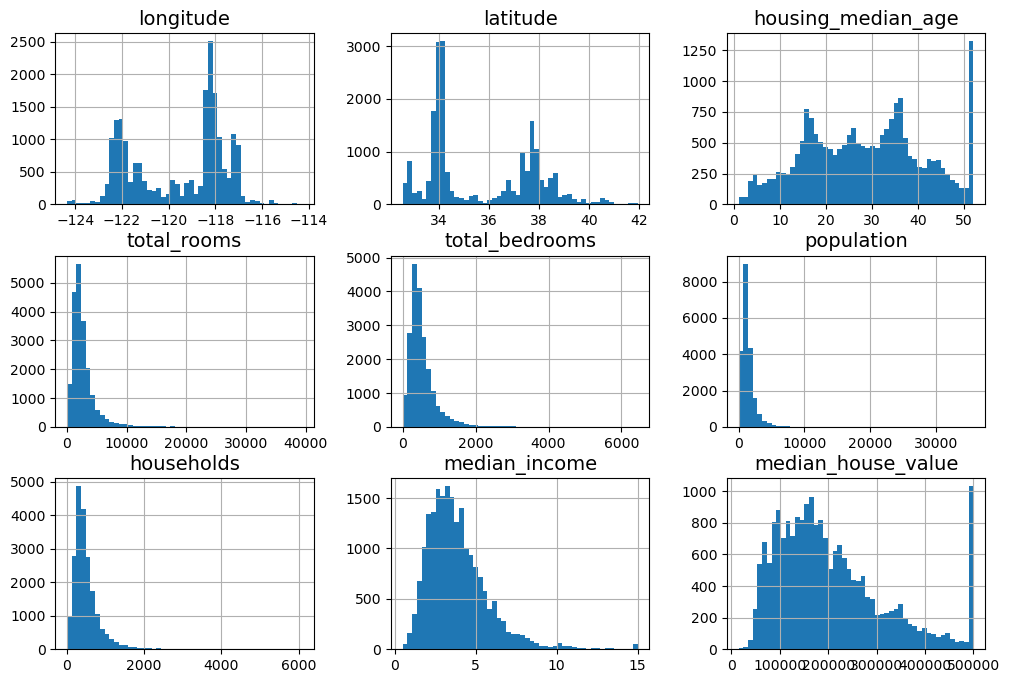

In [9]:
import matplotlib.pyplot as plt

# extra code – the next 5 lines define the default font sizes
plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

# Generate histograms for each numerical column in the housing DataFrame
housing.hist(bins=50, figsize=(12, 8)) # Plot histograms with 50 bins and a figure size of 12x8 inches
#save_fig("attribute_histogram_plots")  # extra code
plt.show()

In [10]:
import numpy as np  # Importing the numpy library, which provides support for large, multi-dimensional arrays and matrices

def shuffle_and_split_data(data, test_ratio):
    # Shuffle the indices of the data randomly
    shuffled_indices = np.random.permutation(len(data)) #generates a randomly shuffled array of indices from 0 to the length of the dataset minus one. This ensures that the data is randomly shuffled before splitting.

    # Calculate the size of the test set based on the test_ratio
    test_set_size = int(len(data) * test_ratio)

    # Select the first part of the shuffled indices as the test set indices
    test_indices = shuffled_indices[:test_set_size]

    # Select the remaining part of the shuffled indices as the training set indices
    train_indices = shuffled_indices[test_set_size:]

    # Return the training and test sets based on the indices
    return data.iloc[train_indices], data.iloc[test_indices]

In [11]:
# Split the housing data into a training set and a test set with a 20% test size
train_set, test_set = shuffle_and_split_data(housing, 0.2)

# Output the length of the training set to verify the split
len(train_set)

16512

In [12]:
len(test_set)

4128

In [13]:
test_set["total_bedrooms"].isnull().sum()

np.int64(35)

In [14]:
np.random.seed(42)

In [18]:
from sklearn.model_selection import train_test_split
# Split the housing data into a training set and a test set with a 20% test size
train_set, test_set = train_test_split(housing, test_size=0.2, random_state=42)

In [19]:
test_set["total_bedrooms"].isnull().sum()

np.int64(207)

In [20]:
housing["income_cat"] = pd.cut(housing["median_income"],
                               bins=[0., 1.5, 3.0, 4.5, 6., np.inf],
                               labels=[1, 2, 3, 4, 5])

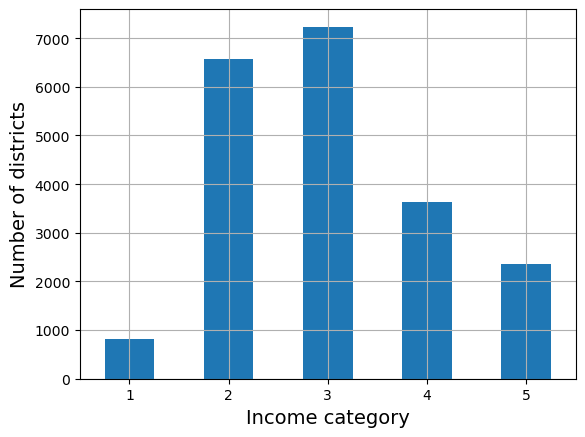

In [21]:
housing["income_cat"].value_counts().sort_index().plot.bar(rot=0, grid=True)
plt.xlabel("Income category")
plt.ylabel("Number of districts")
#save_fig("housing_income_cat_bar_plot")  # extra code
plt.show()

In [22]:
from sklearn.model_selection import StratifiedShuffleSplit  # Importing StratifiedShuffleSplit for creating stratified train-test splits

# Initialize the StratifiedShuffleSplit object with 10 splits, 20% test size, and a random state for reproducibility
splitter = StratifiedShuffleSplit(n_splits=10, test_size=0.2, random_state=42)

# Initialize an empty list to store the stratified splits
strat_splits = []

# Iterate through the splits generated by the StratifiedShuffleSplit object
for train_index, test_index in splitter.split(housing, housing["income_cat"]):
    # Create the training set using the train indices
    strat_train_set_n = housing.iloc[train_index]

    # Create the test set using the test indices
    strat_test_set_n = housing.iloc[test_index]

    # Append the training and test sets as a pair to the list of stratified splits
    strat_splits.append([strat_train_set_n, strat_test_set_n])

In [23]:
# Extract the first pair of stratified training and test sets
strat_train_set, strat_test_set = strat_splits[0]

In [24]:
strat_train_set, strat_test_set = train_test_split(
    housing, test_size=0.2, stratify=housing["income_cat"], random_state=42)

In [25]:
strat_test_set["income_cat"].value_counts() / len(strat_test_set)

income_cat
3    0.350533
2    0.318798
4    0.176357
5    0.114341
1    0.039971
Name: count, dtype: float64

In [26]:
def income_cat_proportions(data):
    return data["income_cat"].value_counts() / len(data)

train_set, test_set = train_test_split(housing, test_size=0.2, random_state=42)

compare_props = pd.DataFrame({
    "Overall %": income_cat_proportions(housing),
    "Stratified %": income_cat_proportions(strat_test_set),
    "Random %": income_cat_proportions(test_set),
}).sort_index()
compare_props.index.name = "Income Category"
compare_props["Strat. Error %"] = (compare_props["Stratified %"] /
                                   compare_props["Overall %"] - 1)
compare_props["Rand. Error %"] = (compare_props["Random %"] /
                                  compare_props["Overall %"] - 1)
(compare_props * 100).round(2)

,Overall %,Stratified %,Random %,Strat. Error %,Rand. Error %
Income Category,,,,,
1,3.98,4.00,4.02,0.36,0.97
2,31.88,31.88,32.44,-0.02,1.73
3,35.06,35.05,35.85,-0.01,2.27
4,17.63,17.64,16.74,0.03,-5.06
5,11.44,11.43,10.95,-0.08,-4.32


In [27]:
for set_ in (strat_train_set, strat_test_set):
    set_.drop("income_cat", axis=1, inplace=True)

In [28]:
#creates a copy of the strat_train_set DataFrame
housing = strat_train_set.copy()

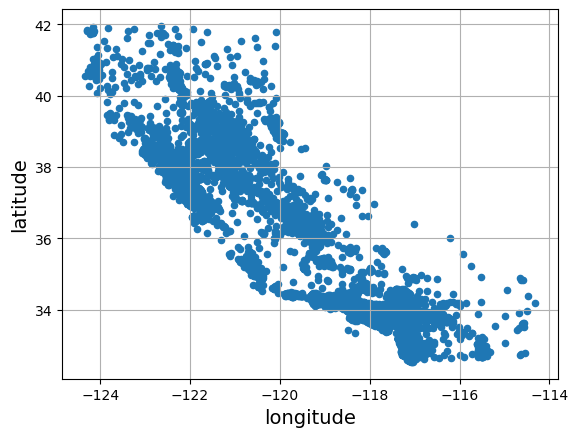

In [29]:
housing.plot(kind="scatter", x="longitude", y="latitude", grid=True)
#save_fig("bad_visualization_plot")  # extra code
plt.show()
     

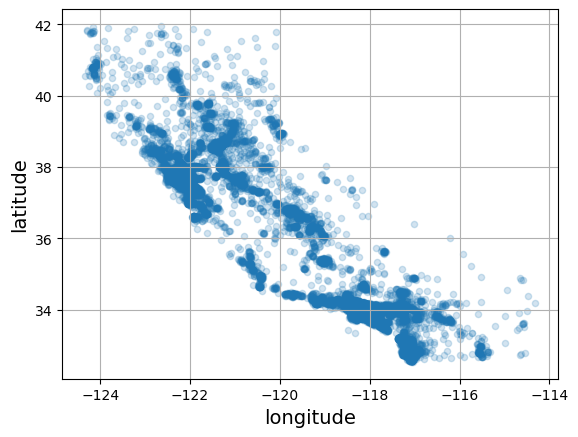

In [30]:
housing.plot(kind="scatter", x="longitude", y="latitude", grid=True, alpha=0.2)
#save_fig("better_visualization_plot")  # extra code
plt.show()

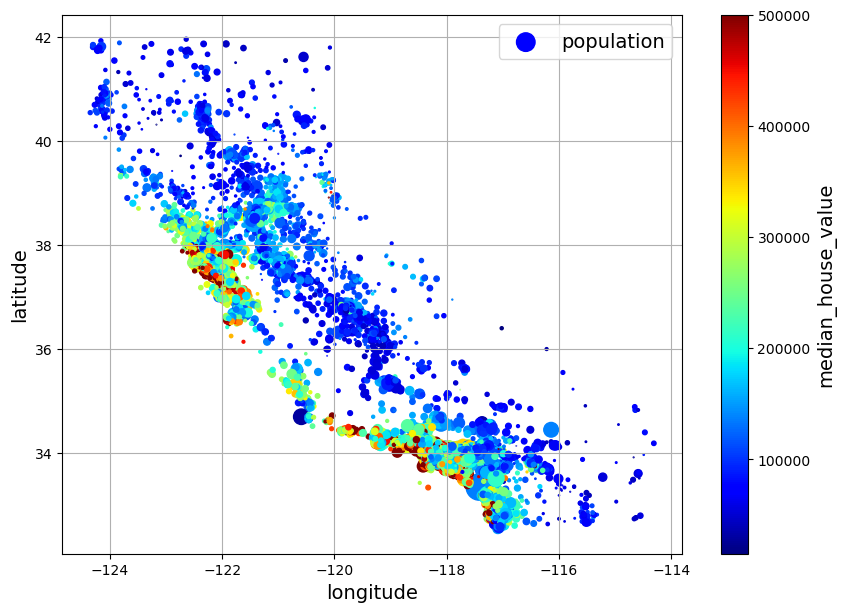

In [31]:
housing.plot(kind="scatter", x="longitude", y="latitude", grid=True,
             s=housing["population"] / 100, label="population",
             c="median_house_value", cmap="jet", colorbar=True,
             legend=True, sharex=False, figsize=(10, 7))
#save_fig("housing_prices_scatterplot")  # extra code
plt.show()

In [32]:
corr_matrix = housing.corr(numeric_only=True)
corr_matrix["median_house_value"].sort_values(ascending=False)
     

median_house_value    1.000000
median_income         0.687151
total_rooms           0.135140
housing_median_age    0.114146
households            0.064590
total_bedrooms        0.047781
population           -0.026882
longitude            -0.047466
latitude             -0.142673
Name: median_house_value, dtype: float64

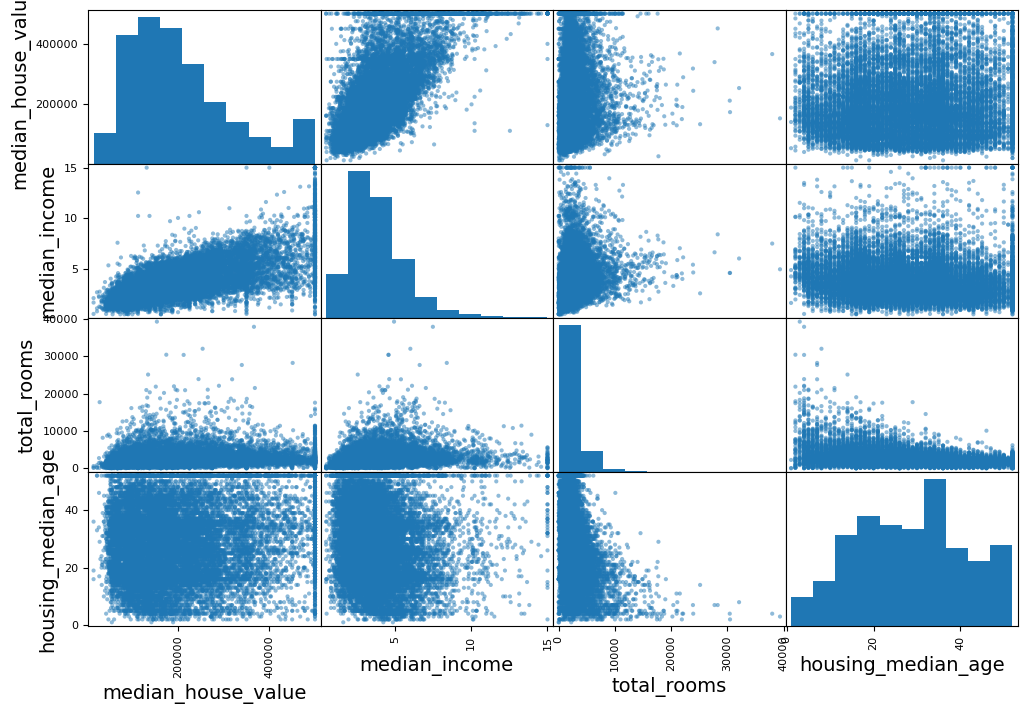

In [33]:
from pandas.plotting import scatter_matrix

attributes = ["median_house_value", "median_income", "total_rooms",
              "housing_median_age"]
scatter_matrix(housing[attributes], figsize=(12, 8))
#save_fig("scatter_matrix_plot")  # extra code
plt.show()

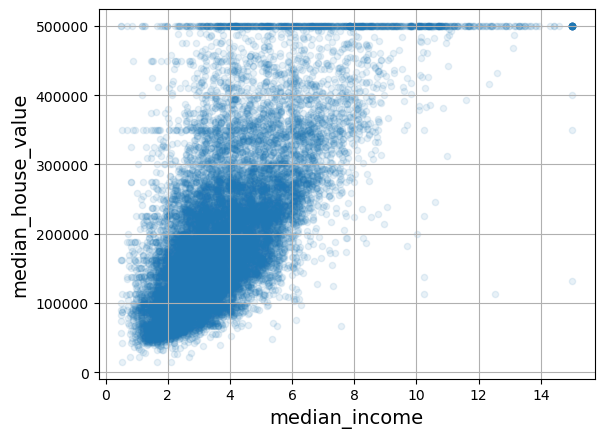

In [34]:
housing.plot(kind="scatter", x="median_income", y="median_house_value",
             alpha=0.1, grid=True)
#save_fig("income_vs_house_value_scatterplot")  # extra code
plt.show()

In [35]:
housing["rooms_per_house"] = housing["total_rooms"] / housing["households"]
housing["bedrooms_ratio"] = housing["total_bedrooms"] / housing["total_rooms"]
housing["people_per_house"] = housing["population"] / housing["households"]

In [36]:
corr_matrix = housing.corr(numeric_only=True)
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.687151
rooms_per_house       0.146255
total_rooms           0.135140
housing_median_age    0.114146
households            0.064590
total_bedrooms        0.047781
people_per_house     -0.021991
population           -0.026882
longitude            -0.047466
latitude             -0.142673
bedrooms_ratio       -0.259952
Name: median_house_value, dtype: float64

In [37]:
# Create a new DataFrame, housing, which contains all the features (input data) except the target variable, median_house_value
strat_housing = strat_train_set.drop("median_house_value", axis=1)
# Create a new Series, housing_labels, which contains the target variable, median_house_value
strat_housing_labels = strat_train_set["median_house_value"].copy()
#The housing_labels Series now contains the target variable values, which will be used for training the machine learning model.
    

In [38]:
housing.info()

<class 'pandas.DataFrame'>
Index: 16512 entries, 12655 to 19773
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           16512 non-null  float64
 1   latitude            16512 non-null  float64
 2   housing_median_age  16512 non-null  float64
 3   total_rooms         16512 non-null  float64
 4   total_bedrooms      16354 non-null  float64
 5   population          16512 non-null  float64
 6   households          16512 non-null  float64
 7   median_income       16512 non-null  float64
 8   median_house_value  16512 non-null  float64
 9   ocean_proximity     16512 non-null  str    
 10  rooms_per_house     16512 non-null  float64
 11  bedrooms_ratio      16354 non-null  float64
 12  people_per_house    16512 non-null  float64
dtypes: float64(12), str(1)
memory usage: 1.8 MB


In [39]:
null_rows_idx = strat_housing.isnull().any(axis=1)
strat_housing.loc[null_rows_idx].head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
1606,-122.08,37.88,26.0,2947.0,NaN,825.0,626.0,2.9330,NEAR BAY
10915,-117.87,33.73,45.0,2264.0,NaN,1970.0,499.0,3.4193,<1H OCEAN
19150,-122.70,38.35,14.0,2313.0,NaN,954.0,397.0,3.7813,<1H OCEAN
4186,-118.23,34.13,48.0,1308.0,NaN,835.0,294.0,4.2891,<1H OCEAN
16885,-122.40,37.58,26.0,3281.0,NaN,1145.0,480.0,6.3580,NEAR OCEAN


In [40]:
# Import the SimpleImputer class from the sklearn.impute module
from sklearn.impute import SimpleImputer

# Create an imputer instance with the strategy to fill missing values with the median value
imputer = SimpleImputer(strategy="median")

In [41]:
# Select only the numerical columns from the housing DataFrame and assign them to housing_num
strat_housing_num = strat_housing.select_dtypes(include=[np.number])

In [42]:
# Fit the SimpleImputer instance to the numerical columns of the housing DataFrame
# This calculates the median values for each numerical column and stores them in the imputer
imputer.fit(strat_housing_num)

,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False


In [43]:
imputer.statistics_

array([-118.51   ,   34.26   ,   29.     , 2119.     ,  433.     ,
       1164.     ,  408.     ,    3.54155])

In [44]:
strat_housing_num.median().values

array([-118.51   ,   34.26   ,   29.     , 2119.     ,  433.     ,
       1164.     ,  408.     ,    3.54155])

In [45]:
# Transform the numerical columns of the housing DataFrame using the fitted SimpleImputer
# This fills in missing values with the median values calculated during the fitting step
X = imputer.transform(strat_housing_num)
     

In [46]:
# Retrieve the names of the features that the SimpleImputer was fitted on
# This provides a list of column names that were included in the imputation process
imputer.feature_names_in_

array(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income'],
      dtype=object)

In [47]:
# Convert the NumPy array resulting from the imputation back into a DataFrame
# Restore the original column names and row indices from the housing_num DataFrame
strat_housing_tr = pd.DataFrame(X, columns=strat_housing_num.columns,
                          index=strat_housing_num.index)

In [48]:
strat_housing_tr.loc[null_rows_idx].head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
1606,-122.08,37.88,26.0,2947.0,433.0,825.0,626.0,2.9330
10915,-117.87,33.73,45.0,2264.0,433.0,1970.0,499.0,3.4193
19150,-122.70,38.35,14.0,2313.0,433.0,954.0,397.0,3.7813
4186,-118.23,34.13,48.0,1308.0,433.0,835.0,294.0,4.2891
16885,-122.40,37.58,26.0,3281.0,433.0,1145.0,480.0,6.3580


In [49]:
imputer.strategy

'median'

In [50]:
from sklearn.ensemble import IsolationForest

# Create an instance of the IsolationForest with a fixed random state for reproducibility
isolation_forest = IsolationForest(random_state=42)

# Fit the IsolationForest model to the data and predict outliers
outlier_pred = isolation_forest.fit_predict(X)

In [51]:
# The fit_predict method returns an array where 1 indicates an inlier and -1 indicates an outlier
outlier_pred

array([ 1, -1,  1, ...,  1,  1,  1], shape=(16512,))

In [52]:
# Extract the 'ocean_proximity' column from the housing DataFrame and assign it to housing_cat
strat_housing_cat = strat_housing[["ocean_proximity"]]

# Display the first 8 rows of the housing_cat DataFrame to preview the 'ocean_proximity' data
strat_housing_cat.head(8)

,ocean_proximity
12655,INLAND
15502,NEAR OCEAN
2908,INLAND
14053,NEAR OCEAN
20496,<1H OCEAN
1481,NEAR BAY
18125,<1H OCEAN
5830,<1H OCEAN


In [53]:
# Import the OrdinalEncoder from sklearn.preprocessing
from sklearn.preprocessing import OrdinalEncoder

# Create an instance of the OrdinalEncoder
ordinal_encoder = OrdinalEncoder()

# Fit the OrdinalEncoder to the housing_cat data and transform it into numerical values
strat_housing_cat_encoded = ordinal_encoder.fit_transform(strat_housing_cat)

In [54]:
strat_housing_cat_encoded[:8]

array([[1.],
       [4.],
       [1.],
       [4.],
       [0.],
       [3.],
       [0.],
       [0.]])

In [55]:
ordinal_encoder.categories_

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

In [56]:
# Import the MinMaxScaler from sklearn.preprocessing
from sklearn.preprocessing import MinMaxScaler

# Create an instance of the MinMaxScaler with the feature range set to [-1, 1]
min_max_scaler = MinMaxScaler(feature_range=(-1, 1))

# Fit the MinMaxScaler to the housing_num data and transform it
# This scales each numerical feature to the range [-1, 1]
strat_housing_num_min_max_scaled = min_max_scaler.fit_transform(strat_housing_num)

In [57]:
# Import the StandardScaler from sklearn.preprocessing
from sklearn.preprocessing import StandardScaler

# Create an instance of the StandardScaler
std_scaler = StandardScaler()

# Fit the StandardScaler to the housing_num data and transform it
# This standardizes each numerical feature by removing the mean and scaling to unit variance
strat_housing_num_std_scaled = std_scaler.fit_transform(strat_housing_num)

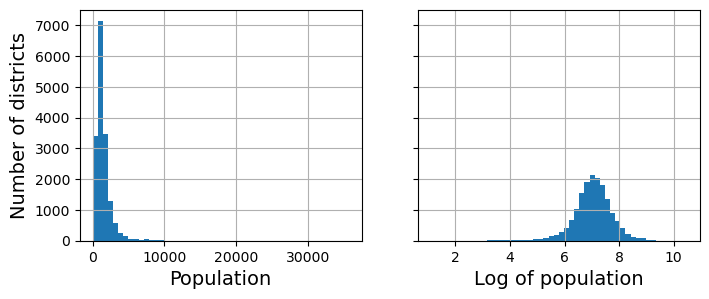

In [58]:
# extra code – this cell generates Figure 2–17 in the Book
fig, axs = plt.subplots(1, 2, figsize=(8, 3), sharey=True)
strat_housing["population"].hist(ax=axs[0], bins=50)
strat_housing["population"].apply(np.log).hist(ax=axs[1], bins=50)
axs[0].set_xlabel("Population")
axs[1].set_xlabel("Log of population")
axs[0].set_ylabel("Number of districts")
#save_fig("long_tail_plot")
plt.show()

In [59]:
# Import the rbf_kernel function from sklearn.metrics.pairwise
from sklearn.metrics.pairwise import rbf_kernel

# Compute the RBF kernel similarity between the housing_median_age feature and the age 35
# The gamma parameter controls the influence of a single training example
age_simil_35 = rbf_kernel(strat_housing[["housing_median_age"]], [[35]], gamma=0.1)
     

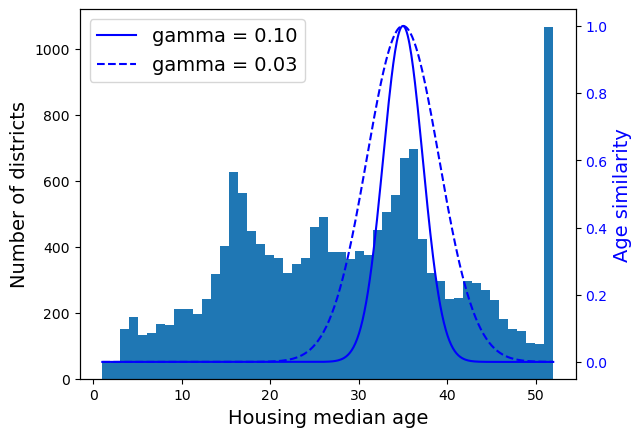

In [60]:
ages = np.linspace(strat_housing["housing_median_age"].min(),
                   strat_housing["housing_median_age"].max(),
                   500).reshape(-1, 1)
gamma1 = 0.1
gamma2 = 0.03
rbf1 = rbf_kernel(ages, [[35]], gamma=gamma1)
rbf2 = rbf_kernel(ages, [[35]], gamma=gamma2)

fig, ax1 = plt.subplots()

ax1.set_xlabel("Housing median age")
ax1.set_ylabel("Number of districts")
ax1.hist(strat_housing["housing_median_age"], bins=50)

ax2 = ax1.twinx()  # create a twin axis that shares the same x-axis
color = "blue"
ax2.plot(ages, rbf1, color=color, label="gamma = 0.10")
ax2.plot(ages, rbf2, color=color, label="gamma = 0.03", linestyle="--")
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_ylabel("Age similarity", color=color)

plt.legend(loc="upper left")
#save_fig("age_similarity_plot")
plt.show()

In [61]:
# Import the FunctionTransformer from sklearn.preprocessing
from sklearn.preprocessing import FunctionTransformer

# Create a FunctionTransformer for the logarithmic transformation
# np.log applies the natural logarithm, and np.exp is the inverse function
log_transformer = FunctionTransformer(np.log, inverse_func=np.exp)

# Apply the logarithmic transformation to the population feature
log_pop = log_transformer.transform(strat_housing[["population"]])

In [62]:
# Create a FunctionTransformer for the RBF kernel transformation
# rbf_kernel computes the RBF kernel similarity, with Y=[[35.]] and gamma=0.1 as additional arguments
rbf_transformer = FunctionTransformer(rbf_kernel,
                                      kw_args=dict(Y=[[35.]], gamma=0.1))

# Apply the RBF kernel transformation to the housing_median_age feature
age_simil_35 = rbf_transformer.transform(strat_housing[["housing_median_age"]])

In [63]:
age_simil_35

array([[2.73237224e-02],
       [8.93948745e-35],
       [3.03539138e-04],
       ...,
       [4.57533877e-08],
       [7.04065961e-20],
       [1.66155727e-03]], shape=(16512, 1))

In [64]:
# Define the coordinates of San Francisco (latitude, longitude)
sf_coords = 37.7749, -122.41

# Create a FunctionTransformer for the RBF kernel transformation
# rbf_kernel computes the RBF kernel similarity, with San Francisco's coordinates and gamma=0.1
sf_transformer = FunctionTransformer(rbf_kernel,
                                     kw_args=dict(Y=[sf_coords], gamma=0.1))


# Apply the RBF kernel transformation to the latitude and longitude features
# This computes the similarity of each housing unit's coordinates to San Francisco's coordinates
sf_simil = sf_transformer.transform(strat_housing[["latitude", "longitude"]])

In [65]:
sf_simil

array([[0.86435873],
       [0.0076117 ],
       [0.18013578],
       ...,
       [0.94757821],
       [0.9636345 ],
       [0.61315569]], shape=(16512, 1))

In [66]:
# Create a FunctionTransformer to calculate the ratio of the first column to the second column
ratio_transformer = FunctionTransformer(lambda X: X[:, [0]] / X[:, [1]])

# Apply the ratio transformer to a sample 2D NumPy array
# This computes the ratio for each row: first column value divided by second column value
ratio_transformer.transform(np.array([[1., 2.], [3., 4.]]))

array([[0.5 ],
       [0.75]])

In [67]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.utils.validation import check_array, check_is_fitted

# Define a custom transformer class for standard scaling
class StandardScalerClone(BaseEstimator, TransformerMixin):
    def __init__(self, with_mean=True):  # Initialize with an optional with_mean parameter
        self.with_mean = with_mean

    def fit(self, X, y=None): # Fit method to calculate mean and scale # y is required even though we don't use it
        X = check_array(X) # Validate input array # checks that X is an array with finite float values
        self.mean_ = X.mean(axis=0) # Calculate mean of each feature
        self.scale_ = X.std(axis=0) # Calculate standard deviation of each feature
        self.n_features_in_ = X.shape[1]  # Store the number of features # every estimator stores this in fit()
        return self  # always return self!

    def transform(self, X): # Transform method to standardize the data
        check_is_fitted(self)  # Ensure the transformer has been fitted
        X = check_array(X) # Validate input array
        assert self.n_features_in_ == X.shape[1] # Ensure the number of features matches
        if self.with_mean:
            X = X - self.mean_  # Center the data by subtracting the mean if with_mean is True
        return X / self.scale_ # Scale the data by dividing by the standard deviation
     

In [68]:
# Import the KMeans class from sklearn.cluster
from sklearn.cluster import KMeans

# Define a custom transformer class for cluster similarity using K-means and RBF kernel
class ClusterSimilarity(BaseEstimator, TransformerMixin):
    def __init__(self, n_clusters=10, gamma=1.0, random_state=None):
        # Initialize with parameters for the number of clusters, RBF kernel gamma, and random state
        self.n_clusters = n_clusters
        self.gamma = gamma
        self.random_state = random_state

    def fit(self, X, y=None, sample_weight=None):
        # Create and fit a K-means model with the specified number of clusters and random state
        self.kmeans_ = KMeans(self.n_clusters, n_init=10,
                              random_state=self.random_state)
        self.kmeans_.fit(X, sample_weight=sample_weight)
        return self  # always return self!

    def transform(self, X):
        # Transform the data by computing the RBF kernel similarity to the cluster centers
        return rbf_kernel(X, self.kmeans_.cluster_centers_, gamma=self.gamma)

    def get_feature_names_out(self, names=None):
        # Generate feature names for the transformed data
        return [f"Cluster {i} similarity" for i in range(self.n_clusters)]

In [69]:
cluster_simil = ClusterSimilarity(n_clusters=10, gamma=1., random_state=42)
similarities = cluster_simil.fit_transform(strat_housing[["latitude", "longitude"]],
                                           sample_weight=strat_housing_labels)

In [70]:
similarities[:3].round(2)

array([[0.  , 0.31, 0.  , 0.85, 0.  , 0.  , 0.  , 0.  , 0.16, 0.49],
       [0.11, 0.  , 0.  , 0.  , 0.94, 0.  , 0.  , 0.41, 0.  , 0.  ],
       [0.11, 0.  , 0.15, 0.  , 0.  , 0.37, 0.  , 0.02, 0.  , 0.  ]])

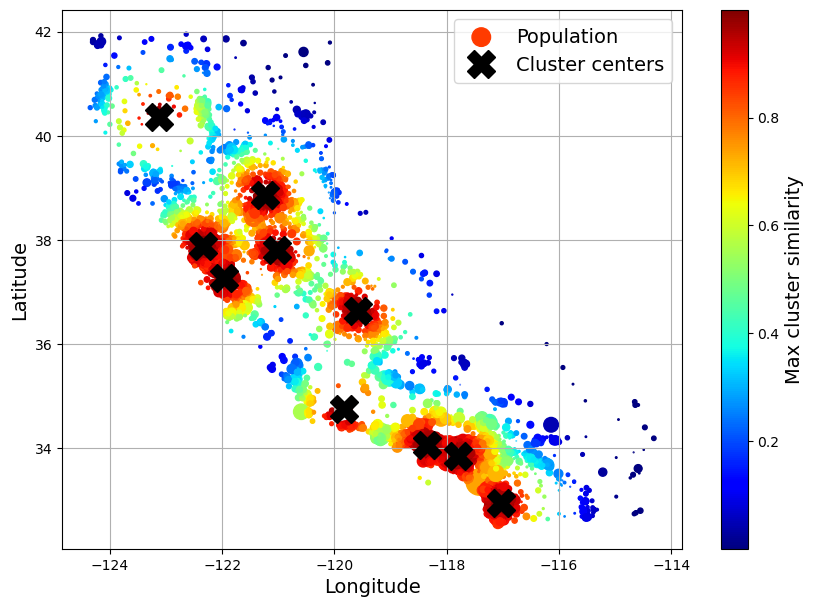

In [71]:

strat_housing_renamed = strat_housing.rename(columns={
    "latitude": "Latitude", "longitude": "Longitude",
    "population": "Population",
    "median_house_value": "Median house value (ᴜsᴅ)"})
strat_housing_renamed["Max cluster similarity"] = similarities.max(axis=1)

strat_housing_renamed.plot(kind="scatter", x="Longitude", y="Latitude", grid=True,
                     s=strat_housing_renamed["Population"] / 100, label="Population",
                     c="Max cluster similarity",
                     cmap="jet", colorbar=True,
                     legend=True, sharex=False, figsize=(10, 7))
plt.plot(cluster_simil.kmeans_.cluster_centers_[:, 1],
         cluster_simil.kmeans_.cluster_centers_[:, 0],
         linestyle="", color="black", marker="X", markersize=20,
         label="Cluster centers")
plt.legend(loc="upper right")
#save_fig("district_cluster_plot")
plt.show()

In [72]:
from sklearn.pipeline import Pipeline

# Create a pipeline for preprocessing numerical attributes
# The pipeline includes two steps: imputation and standardization
num_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="median")), # Step 1: Impute missing values with the median
    ("standardize", StandardScaler()), # Step 2: Standardize features to have mean=0 and variance=1
])

In [73]:
from sklearn.pipeline import make_pipeline

# Create a pipeline for preprocessing numerical attributes using make_pipeline
# The pipeline also includes two steps: imputation and standardization
num_pipeline = make_pipeline(SimpleImputer(strategy="median"), StandardScaler())

In [74]:
from sklearn import set_config

set_config(display='diagram')

num_pipeline

,steps,"[('simpleimputer', ...), ('standardscaler', ...)]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,copy,True


In [75]:
strat_housing_num_prepared = num_pipeline.fit_transform(strat_housing_num)
strat_housing_num_prepared[:2].round(2)

array([[-0.94,  1.35,  0.03,  0.58,  0.64,  0.73,  0.56, -0.89],
       [ 1.17, -1.19, -1.72,  1.26,  0.78,  0.53,  0.72,  1.29]])

In [76]:
df_housing_num_prepared = pd.DataFrame(
    strat_housing_num_prepared, columns=num_pipeline.get_feature_names_out(),
    index=strat_housing_num.index)
     

In [77]:
df_housing_num_prepared.head(2)  # extra code to check the feature names

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
12655,-0.941350,1.347438,0.027564,0.584777,0.640371,0.732602,0.556286,-0.893647
15502,1.171782,-1.192440,-1.722018,1.261467,0.781561,0.533612,0.721318,1.292168


In [78]:
num_pipeline.steps

[('simpleimputer', SimpleImputer(strategy='median')),
 ('standardscaler', StandardScaler())]

In [79]:
num_pipeline[1]

,copy,True
,with_mean,True
,with_std,True


In [80]:
num_pipeline[:-1]

,steps,"[('simpleimputer', ...)]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False


In [81]:
num_pipeline.named_steps["simpleimputer"]

,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False


In [82]:
num_pipeline.set_params(simpleimputer__strategy="median")

,steps,"[('simpleimputer', ...), ('standardscaler', ...)]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,copy,True


In [83]:
# Import the ColumnTransformer class from sklearn.compose
from sklearn.compose import ColumnTransformer

# Define the numerical attributes
num_attribs = ["longitude", "latitude", "housing_median_age", "total_rooms",
               "total_bedrooms", "population", "households", "median_income"]

# Define the categorical attributes
cat_attribs = ["ocean_proximity"]

# Create a pipeline for preprocessing categorical attributes
cat_pipeline = make_pipeline(
    SimpleImputer(strategy="most_frequent"), # Step 1: Impute missing values with the most frequent value
    OneHotEncoder(handle_unknown="ignore"))  # Step 2: One-hot encode categorical features and ignore unknown categories

# Combine numerical and categorical pipelines using ColumnTransformer
preprocessing = ColumnTransformer([
    ("num", num_pipeline, num_attribs), # Apply the numerical pipeline to numerical attributes
    ("cat", cat_pipeline, cat_attribs),  # Apply the categorical pipeline to categorical attributes
])

In [84]:
from sklearn.compose import make_column_selector, make_column_transformer

In [85]:
strat_housing_prepared = preprocessing.fit_transform(strat_housing)

In [86]:
# extra code – shows that we can get a DataFrame out if we want
strat_housing_prepared_fr = pd.DataFrame(
    strat_housing_prepared,
    columns=preprocessing.get_feature_names_out(),
    index=strat_housing.index)
strat_housing_prepared_fr.head(2)

,num__longitude,num__latitude,num__housing_median_age,num__total_rooms,num__total_bedrooms,num__population,num__households,num__median_income,cat__ocean_proximity_<1H OCEAN,cat__ocean_proximity_INLAND,cat__ocean_proximity_ISLAND,cat__ocean_proximity_NEAR BAY,cat__ocean_proximity_NEAR OCEAN
12655,-0.941350,1.347438,0.027564,0.584777,0.640371,0.732602,0.556286,-0.893647,0.0,1.0,0.0,0.0,0.0
15502,1.171782,-1.192440,-1.722018,1.261467,0.781561,0.533612,0.721318,1.292168,0.0,0.0,0.0,0.0,1.0
